In [252]:
import numpy as np
import pandas as pd
import seaborn as sns

In [253]:
df= pd.read_csv("7_real_estate_prices.csv")

In [254]:
df.describe

<bound method NDFrame.describe of          property_id listing_date  property_type     city neighborhood_tier  \
0      PROP_00000001   17-09-2023          Condo   Denver           Premium   
1      PROP_00000002   27-04-2023  Single Family  Seattle           Premium   
2      PROP_00000003   28-11-2023  Single Family   Austin           Average   
3      PROP_00000004   15-02-2023  Single Family   Austin              Good   
4      PROP_00000005   07-11-2023  Single Family  Atlanta           Premium   
...              ...          ...            ...      ...               ...   
14995  PROP_00014996   03-11-2023      Townhouse  Seattle           Average   
14996  PROP_00014997   19-01-2023  Single Family  Seattle           Premium   
14997  PROP_00014998   02-01-2023          Condo   Denver              Good   
14998  PROP_00014999   21-08-2023  Single Family  Atlanta              Good   
14999  PROP_00015000   19-05-2023  Single Family  Seattle        Developing   

       zipcode_cr

In [255]:
df.columns

Index(['property_id', 'listing_date', 'property_type', 'city',
       'neighborhood_tier', 'zipcode_crime_rate', 'school_rating',
       'distance_to_downtown_miles', 'walk_score', 'bedrooms', 'bathrooms',
       'square_feet', 'lot_size_sqft', 'stories', 'garage_spaces',
       'year_built', 'house_age', 'has_basement', 'has_pool',
       'overall_condition', 'kitchen_quality', 'hvac_condition',
       'roof_condition', 'renovation_year', 'years_since_renovation',
       'days_on_market', 'listing_season', 'market_trend', 'interest_rate',
       'has_fireplace', 'has_patio_deck', 'has_security_system', 'hoa_fees',
       'sale_price', 'high_value_property'],
      dtype='str')

In [256]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   property_id                 15000 non-null  str    
 1   listing_date                15000 non-null  str    
 2   property_type               15000 non-null  str    
 3   city                        15000 non-null  str    
 4   neighborhood_tier           15000 non-null  str    
 5   zipcode_crime_rate          15000 non-null  float64
 6   school_rating               15000 non-null  int64  
 7   distance_to_downtown_miles  15000 non-null  float64
 8   walk_score                  15000 non-null  int64  
 9   bedrooms                    15000 non-null  int64  
 10  bathrooms                   15000 non-null  float64
 11  square_feet                 14250 non-null  float64
 12  lot_size_sqft               15000 non-null  int64  
 13  stories                     15000 non-null

In [257]:
unique_values = df['property_type'].unique()
unique_values

<StringArray>
['Condo', 'Single Family', 'Townhouse', 'Multi-Family']
Length: 4, dtype: str

In [258]:
null_columns = df.columns[df.isnull().any()]
print(list(null_columns))

['square_feet', 'renovation_year', 'hoa_fees']


In [259]:
#df['hoa_fees'] = df['hoa_fees'].fillna(0).where(df['property_type']!="Condo")
df.loc[(df['property_type'] != 'Condo') & (df['hoa_fees'].isna()), 'hoa_fees'] = 0
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   property_id                 15000 non-null  str    
 1   listing_date                15000 non-null  str    
 2   property_type               15000 non-null  str    
 3   city                        15000 non-null  str    
 4   neighborhood_tier           15000 non-null  str    
 5   zipcode_crime_rate          15000 non-null  float64
 6   school_rating               15000 non-null  int64  
 7   distance_to_downtown_miles  15000 non-null  float64
 8   walk_score                  15000 non-null  int64  
 9   bedrooms                    15000 non-null  int64  
 10  bathrooms                   15000 non-null  float64
 11  square_feet                 14250 non-null  float64
 12  lot_size_sqft               15000 non-null  int64  
 13  stories                     15000 non-null

In [260]:
df_cleaned = df.dropna(subset=['hoa_fees'])
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 14799 entries, 0 to 14999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   property_id                 14799 non-null  str    
 1   listing_date                14799 non-null  str    
 2   property_type               14799 non-null  str    
 3   city                        14799 non-null  str    
 4   neighborhood_tier           14799 non-null  str    
 5   zipcode_crime_rate          14799 non-null  float64
 6   school_rating               14799 non-null  int64  
 7   distance_to_downtown_miles  14799 non-null  float64
 8   walk_score                  14799 non-null  int64  
 9   bedrooms                    14799 non-null  int64  
 10  bathrooms                   14799 non-null  float64
 11  square_feet                 14059 non-null  float64
 12  lot_size_sqft               14799 non-null  int64  
 13  stories                     14799 non-null  int

In [261]:
df_cleaned['square_feet'] = df_cleaned['square_feet'].fillna(df_cleaned['lot_size_sqft'])


In [262]:
df_cleaned['renovation_year'] = df_cleaned['renovation_year'].fillna( df_cleaned['year_built']  )
filtered_df = df_cleaned.loc[df_cleaned['renovation_year'] == df_cleaned['year_built'], ['renovation_year', 'year_built']]
df_cleaned

,property_id,listing_date,property_type,city,neighborhood_tier,zipcode_crime_rate,school_rating,distance_to_downtown_miles,walk_score,bedrooms,...,days_on_market,listing_season,market_trend,interest_rate,has_fireplace,has_patio_deck,has_security_system,hoa_fees,sale_price,high_value_property
0,PROP_00000001,17-09-2023,Condo,Denver,Premium,1.33,6,33.5,38,4,...,37,Summer,Stable,6.43,No,Yes,Yes,0.0,822296,Yes
1,PROP_00000002,27-04-2023,Single Family,Seattle,Premium,1.67,6,9.2,85,2,...,5,Fall,Stable,7.15,Yes,Yes,No,307.0,687536,No
2,PROP_00000003,28-11-2023,Single Family,Austin,Average,1.16,6,2.1,98,6,...,7,Fall,Rising,7.48,No,Yes,No,0.0,1207336,Yes
3,PROP_00000004,15-02-2023,Single Family,Austin,Good,0.97,8,2.8,46,4,...,86,Summer,Stable,6.62,Yes,No,No,0.0,938047,Yes
4,PROP_00000005,07-11-2023,Single Family,Atlanta,Premium,2.64,7,10.2,54,3,...,88,Spring,Rising,5.90,Yes,No,No,160.0,691008,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,PROP_00014996,03-11-2023,Townhouse,Seattle,Average,1.34,3,3.7,30,4,...,18,Spring,Rising,5.73,Yes,Yes,Yes,0.0,714235,No
14996,PROP_00014997,19-01-2023,Single Family,Seattle,Premium,2.13,8,12.5,16,4,...,49,Spring,Rising,5.93,Yes,Yes,No,0.0,977953,Yes
14997,PROP_00014998,02-01-2023,Condo,Denver,Good,2.78,7,7.9,44,3,...,11,Fall,Rising,6.16,No,No,No,0.0,750095,No
14998,PROP_00014999,21-08-2023,Single Family,Atlanta,Good,0.08,6,3.5,32,3,...,21,Spring,Rising,6.29,No,Yes,No,0.0,716925,No


In [263]:
df_cleaned['lot_size_sqft'] = df_cleaned['lot_size_sqft'].astype(float)
df_cleaned['renovation_year'] = df_cleaned['renovation_year'].astype(int)
df_cleaned['bathrooms'] = df_cleaned['bathrooms'].astype(int)
df_cleaned

,property_id,listing_date,property_type,city,neighborhood_tier,zipcode_crime_rate,school_rating,distance_to_downtown_miles,walk_score,bedrooms,...,days_on_market,listing_season,market_trend,interest_rate,has_fireplace,has_patio_deck,has_security_system,hoa_fees,sale_price,high_value_property
0,PROP_00000001,17-09-2023,Condo,Denver,Premium,1.33,6,33.5,38,4,...,37,Summer,Stable,6.43,No,Yes,Yes,0.0,822296,Yes
1,PROP_00000002,27-04-2023,Single Family,Seattle,Premium,1.67,6,9.2,85,2,...,5,Fall,Stable,7.15,Yes,Yes,No,307.0,687536,No
2,PROP_00000003,28-11-2023,Single Family,Austin,Average,1.16,6,2.1,98,6,...,7,Fall,Rising,7.48,No,Yes,No,0.0,1207336,Yes
3,PROP_00000004,15-02-2023,Single Family,Austin,Good,0.97,8,2.8,46,4,...,86,Summer,Stable,6.62,Yes,No,No,0.0,938047,Yes
4,PROP_00000005,07-11-2023,Single Family,Atlanta,Premium,2.64,7,10.2,54,3,...,88,Spring,Rising,5.90,Yes,No,No,160.0,691008,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,PROP_00014996,03-11-2023,Townhouse,Seattle,Average,1.34,3,3.7,30,4,...,18,Spring,Rising,5.73,Yes,Yes,Yes,0.0,714235,No
14996,PROP_00014997,19-01-2023,Single Family,Seattle,Premium,2.13,8,12.5,16,4,...,49,Spring,Rising,5.93,Yes,Yes,No,0.0,977953,Yes
14997,PROP_00014998,02-01-2023,Condo,Denver,Good,2.78,7,7.9,44,3,...,11,Fall,Rising,6.16,No,No,No,0.0,750095,No
14998,PROP_00014999,21-08-2023,Single Family,Atlanta,Good,0.08,6,3.5,32,3,...,21,Spring,Rising,6.29,No,Yes,No,0.0,716925,No


In [264]:
df_cleaned.isnull().sum()

property_id                   0
listing_date                  0
property_type                 0
city                          0
neighborhood_tier             0
zipcode_crime_rate            0
school_rating                 0
distance_to_downtown_miles    0
walk_score                    0
bedrooms                      0
bathrooms                     0
square_feet                   0
lot_size_sqft                 0
stories                       0
garage_spaces                 0
year_built                    0
house_age                     0
has_basement                  0
has_pool                      0
overall_condition             0
kitchen_quality               0
hvac_condition                0
roof_condition                0
renovation_year               0
years_since_renovation        0
days_on_market                0
listing_season                0
market_trend                  0
interest_rate                 0
has_fireplace                 0
has_patio_deck                0
has_secu

Feature Creation

In [265]:
df_cleaned = df_cleaned[df_cleaned['square_feet'] <= df_cleaned['lot_size_sqft']]
df_cleaned

,property_id,listing_date,property_type,city,neighborhood_tier,zipcode_crime_rate,school_rating,distance_to_downtown_miles,walk_score,bedrooms,...,days_on_market,listing_season,market_trend,interest_rate,has_fireplace,has_patio_deck,has_security_system,hoa_fees,sale_price,high_value_property
0,PROP_00000001,17-09-2023,Condo,Denver,Premium,1.33,6,33.5,38,4,...,37,Summer,Stable,6.43,No,Yes,Yes,0.0,822296,Yes
2,PROP_00000003,28-11-2023,Single Family,Austin,Average,1.16,6,2.1,98,6,...,7,Fall,Rising,7.48,No,Yes,No,0.0,1207336,Yes
3,PROP_00000004,15-02-2023,Single Family,Austin,Good,0.97,8,2.8,46,4,...,86,Summer,Stable,6.62,Yes,No,No,0.0,938047,Yes
4,PROP_00000005,07-11-2023,Single Family,Atlanta,Premium,2.64,7,10.2,54,3,...,88,Spring,Rising,5.90,Yes,No,No,160.0,691008,No
5,PROP_00000006,27-03-2023,Single Family,Seattle,Developing,3.30,5,1.7,24,1,...,58,Fall,Stable,7.44,No,Yes,No,0.0,566847,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,PROP_00014996,03-11-2023,Townhouse,Seattle,Average,1.34,3,3.7,30,4,...,18,Spring,Rising,5.73,Yes,Yes,Yes,0.0,714235,No
14996,PROP_00014997,19-01-2023,Single Family,Seattle,Premium,2.13,8,12.5,16,4,...,49,Spring,Rising,5.93,Yes,Yes,No,0.0,977953,Yes
14997,PROP_00014998,02-01-2023,Condo,Denver,Good,2.78,7,7.9,44,3,...,11,Fall,Rising,6.16,No,No,No,0.0,750095,No
14998,PROP_00014999,21-08-2023,Single Family,Atlanta,Good,0.08,6,3.5,32,3,...,21,Spring,Rising,6.29,No,Yes,No,0.0,716925,No


In [266]:
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 11492 entries, 0 to 14999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   property_id                 11492 non-null  str    
 1   listing_date                11492 non-null  str    
 2   property_type               11492 non-null  str    
 3   city                        11492 non-null  str    
 4   neighborhood_tier           11492 non-null  str    
 5   zipcode_crime_rate          11492 non-null  float64
 6   school_rating               11492 non-null  int64  
 7   distance_to_downtown_miles  11492 non-null  float64
 8   walk_score                  11492 non-null  int64  
 9   bedrooms                    11492 non-null  int64  
 10  bathrooms                   11492 non-null  int64  
 11  square_feet                 11492 non-null  float64
 12  lot_size_sqft               11492 non-null  float64
 13  stories                     11492 non-null  int

In [267]:
# Ensure datetime format
df_cleaned['listing_date'] = pd.to_datetime(df_cleaned['listing_date'], errors='coerce')

# Now format as DD/MM/YYYY
df_cleaned['listing_date'] = df_cleaned['listing_date'].dt.strftime('%d/%m/%Y')
df_cleaned

C:\Users\JaiGaneshK\AppData\Local\Temp\ipykernel_13160\895679318.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_cleaned['listing_date'] = pd.to_datetime(df_cleaned['listing_date'], errors='coerce')


,property_id,listing_date,property_type,city,neighborhood_tier,zipcode_crime_rate,school_rating,distance_to_downtown_miles,walk_score,bedrooms,...,days_on_market,listing_season,market_trend,interest_rate,has_fireplace,has_patio_deck,has_security_system,hoa_fees,sale_price,high_value_property
0,PROP_00000001,17/09/2023,Condo,Denver,Premium,1.33,6,33.5,38,4,...,37,Summer,Stable,6.43,No,Yes,Yes,0.0,822296,Yes
2,PROP_00000003,28/11/2023,Single Family,Austin,Average,1.16,6,2.1,98,6,...,7,Fall,Rising,7.48,No,Yes,No,0.0,1207336,Yes
3,PROP_00000004,15/02/2023,Single Family,Austin,Good,0.97,8,2.8,46,4,...,86,Summer,Stable,6.62,Yes,No,No,0.0,938047,Yes
4,PROP_00000005,07/11/2023,Single Family,Atlanta,Premium,2.64,7,10.2,54,3,...,88,Spring,Rising,5.90,Yes,No,No,160.0,691008,No
5,PROP_00000006,27/03/2023,Single Family,Seattle,Developing,3.30,5,1.7,24,1,...,58,Fall,Stable,7.44,No,Yes,No,0.0,566847,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,PROP_00014996,03/11/2023,Townhouse,Seattle,Average,1.34,3,3.7,30,4,...,18,Spring,Rising,5.73,Yes,Yes,Yes,0.0,714235,No
14996,PROP_00014997,19/01/2023,Single Family,Seattle,Premium,2.13,8,12.5,16,4,...,49,Spring,Rising,5.93,Yes,Yes,No,0.0,977953,Yes
14997,PROP_00014998,02/01/2023,Condo,Denver,Good,2.78,7,7.9,44,3,...,11,Fall,Rising,6.16,No,No,No,0.0,750095,No
14998,PROP_00014999,21/08/2023,Single Family,Atlanta,Good,0.08,6,3.5,32,3,...,21,Spring,Rising,6.29,No,Yes,No,0.0,716925,No


In [268]:
df_cleaned.duplicated().sum()

np.int64(0)

In [269]:
df_cleaned['price_per_sqft'] = df_cleaned['sale_price'] / df_cleaned['square_feet']
df_cleaned

,property_id,listing_date,property_type,city,neighborhood_tier,zipcode_crime_rate,school_rating,distance_to_downtown_miles,walk_score,bedrooms,...,listing_season,market_trend,interest_rate,has_fireplace,has_patio_deck,has_security_system,hoa_fees,sale_price,high_value_property,price_per_sqft
0,PROP_00000001,17/09/2023,Condo,Denver,Premium,1.33,6,33.5,38,4,...,Summer,Stable,6.43,No,Yes,Yes,0.0,822296,Yes,372.923356
2,PROP_00000003,28/11/2023,Single Family,Austin,Average,1.16,6,2.1,98,6,...,Fall,Rising,7.48,No,Yes,No,0.0,1207336,Yes,390.344649
3,PROP_00000004,15/02/2023,Single Family,Austin,Good,0.97,8,2.8,46,4,...,Summer,Stable,6.62,Yes,No,No,0.0,938047,Yes,430.099496
4,PROP_00000005,07/11/2023,Single Family,Atlanta,Premium,2.64,7,10.2,54,3,...,Spring,Rising,5.90,Yes,No,No,160.0,691008,No,300.046895
5,PROP_00000006,27/03/2023,Single Family,Seattle,Developing,3.30,5,1.7,24,1,...,Fall,Stable,7.44,No,Yes,No,0.0,566847,No,516.254098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,PROP_00014996,03/11/2023,Townhouse,Seattle,Average,1.34,3,3.7,30,4,...,Spring,Rising,5.73,Yes,Yes,Yes,0.0,714235,No,295.994613
14996,PROP_00014997,19/01/2023,Single Family,Seattle,Premium,2.13,8,12.5,16,4,...,Spring,Rising,5.93,Yes,Yes,No,0.0,977953,Yes,357.569653
14997,PROP_00014998,02/01/2023,Condo,Denver,Good,2.78,7,7.9,44,3,...,Fall,Rising,6.16,No,No,No,0.0,750095,No,360.796056
14998,PROP_00014999,21/08/2023,Single Family,Atlanta,Good,0.08,6,3.5,32,3,...,Spring,Rising,6.29,No,Yes,No,0.0,716925,No,437.416107


In [270]:
amenity_cols = ['has_basement', 'has_pool', 'has_fireplace', 'has_patio_deck', 'has_security_system']
df_cleaned['amenity_count'] = df_cleaned[amenity_cols].replace({'Yes': 1, 'No': 0}).sum(axis=1)
df_cleaned

,property_id,listing_date,property_type,city,neighborhood_tier,zipcode_crime_rate,school_rating,distance_to_downtown_miles,walk_score,bedrooms,...,market_trend,interest_rate,has_fireplace,has_patio_deck,has_security_system,hoa_fees,sale_price,high_value_property,price_per_sqft,amenity_count
0,PROP_00000001,17/09/2023,Condo,Denver,Premium,1.33,6,33.5,38,4,...,Stable,6.43,No,Yes,Yes,0.0,822296,Yes,372.923356,2
2,PROP_00000003,28/11/2023,Single Family,Austin,Average,1.16,6,2.1,98,6,...,Rising,7.48,No,Yes,No,0.0,1207336,Yes,390.344649,1
3,PROP_00000004,15/02/2023,Single Family,Austin,Good,0.97,8,2.8,46,4,...,Stable,6.62,Yes,No,No,0.0,938047,Yes,430.099496,1
4,PROP_00000005,07/11/2023,Single Family,Atlanta,Premium,2.64,7,10.2,54,3,...,Rising,5.90,Yes,No,No,160.0,691008,No,300.046895,2
5,PROP_00000006,27/03/2023,Single Family,Seattle,Developing,3.30,5,1.7,24,1,...,Stable,7.44,No,Yes,No,0.0,566847,No,516.254098,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,PROP_00014996,03/11/2023,Townhouse,Seattle,Average,1.34,3,3.7,30,4,...,Rising,5.73,Yes,Yes,Yes,0.0,714235,No,295.994613,4
14996,PROP_00014997,19/01/2023,Single Family,Seattle,Premium,2.13,8,12.5,16,4,...,Rising,5.93,Yes,Yes,No,0.0,977953,Yes,357.569653,3
14997,PROP_00014998,02/01/2023,Condo,Denver,Good,2.78,7,7.9,44,3,...,Rising,6.16,No,No,No,0.0,750095,No,360.796056,0
14998,PROP_00014999,21/08/2023,Single Family,Atlanta,Good,0.08,6,3.5,32,3,...,Rising,6.29,No,Yes,No,0.0,716925,No,437.416107,2


In [271]:


df_cleaned['overall_condition'].unique()

<StringArray>
['Good', 'Fair', 'Poor', 'Excellent']
Length: 4, dtype: str

In [272]:
df_cleaned['kitchen_quality'].unique()

<StringArray>
['Premium', 'Average', 'Good', 'Basic']
Length: 4, dtype: str

In [273]:
df_cleaned['roof_condition'].unique()


<StringArray>
['Good', 'Fair', 'New', 'Needs Replacement']
Length: 4, dtype: str

In [274]:
df_cleaned['hvac_condition'].unique()

<StringArray>
['Old', 'Good', 'Fair', 'New']
Length: 4, dtype: str

In [275]:
# Property Quality Index (PQI)
quality_map = {'New': 5, 'Excellent': 5, 'Good': 4, 'Average': 3, 'Fair': 2, 'Old': 1, 'Poor': 1,'Needs Replacement': 1, 'Basic': 1,'Premium': 5}
comp_cols = [ 'hvac_condition', 'roof_condition', 'overall_condition']
df['quality_index'] = df[comp_cols].apply(lambda x: x.map(quality_map)).sum(axis=1)

In [276]:
# --- 5. Bucketing (Binning) ---
    # House Era
df_cleaned['house_age'] = pd.cut(df_cleaned['house_age'], 
bins=[0, 5, 20, 50, 100], 
labels=['New', 'Modern', 'Established', 'Historic'])
df_cleaned['house_age']

0           Historic
2        Established
3        Established
4           Historic
5        Established
            ...     
14995       Historic
14996       Historic
14997    Established
14998         Modern
14999    Established
Name: house_age, Length: 11492, dtype: category
Categories (4, str): ['New' < 'Modern' < 'Established' < 'Historic']

In [277]:
# Walkability
df_cleaned['walk_category'] = pd.cut(df_cleaned['walk_score'], 
bins=[0, 24, 49, 69, 100], 
labels=['Car-Dependent', 'Somewhat Walkable', 'Very Walkable', 'Walkers Paradise'])
df_cleaned['walk_category']

0        Somewhat Walkable
2         Walkers Paradise
3        Somewhat Walkable
4            Very Walkable
5            Car-Dependent
               ...        
14995    Somewhat Walkable
14996        Car-Dependent
14997    Somewhat Walkable
14998    Somewhat Walkable
14999        Very Walkable
Name: walk_category, Length: 11492, dtype: category
Categories (4, str): ['Car-Dependent' < 'Somewhat Walkable' < 'Very Walkable' < 'Walkers Paradise']

In [278]:
df_cleaned['location_type'] = pd.cut(df_cleaned['distance_to_downtown_miles'], 
bins=[0, 3, 10, 25, 100], 
labels=['Urban Core', 'Inner Suburb', 'Outer Suburb', 'Rural'])
df_cleaned['location_type'] 

0               Rural
2          Urban Core
3          Urban Core
4        Outer Suburb
5          Urban Core
             ...     
14995    Inner Suburb
14996    Outer Suburb
14997    Inner Suburb
14998    Inner Suburb
14999    Outer Suburb
Name: location_type, Length: 11492, dtype: category
Categories (4, str): ['Urban Core' < 'Inner Suburb' < 'Outer Suburb' < 'Rural']

In [279]:
df_cleaned


,property_id,listing_date,property_type,city,neighborhood_tier,zipcode_crime_rate,school_rating,distance_to_downtown_miles,walk_score,bedrooms,...,has_fireplace,has_patio_deck,has_security_system,hoa_fees,sale_price,high_value_property,price_per_sqft,amenity_count,walk_category,location_type
0,PROP_00000001,17/09/2023,Condo,Denver,Premium,1.33,6,33.5,38,4,...,No,Yes,Yes,0.0,822296,Yes,372.923356,2,Somewhat Walkable,Rural
2,PROP_00000003,28/11/2023,Single Family,Austin,Average,1.16,6,2.1,98,6,...,No,Yes,No,0.0,1207336,Yes,390.344649,1,Walkers Paradise,Urban Core
3,PROP_00000004,15/02/2023,Single Family,Austin,Good,0.97,8,2.8,46,4,...,Yes,No,No,0.0,938047,Yes,430.099496,1,Somewhat Walkable,Urban Core
4,PROP_00000005,07/11/2023,Single Family,Atlanta,Premium,2.64,7,10.2,54,3,...,Yes,No,No,160.0,691008,No,300.046895,2,Very Walkable,Outer Suburb
5,PROP_00000006,27/03/2023,Single Family,Seattle,Developing,3.30,5,1.7,24,1,...,No,Yes,No,0.0,566847,No,516.254098,1,Car-Dependent,Urban Core
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,PROP_00014996,03/11/2023,Townhouse,Seattle,Average,1.34,3,3.7,30,4,...,Yes,Yes,Yes,0.0,714235,No,295.994613,4,Somewhat Walkable,Inner Suburb
14996,PROP_00014997,19/01/2023,Single Family,Seattle,Premium,2.13,8,12.5,16,4,...,Yes,Yes,No,0.0,977953,Yes,357.569653,3,Car-Dependent,Outer Suburb
14997,PROP_00014998,02/01/2023,Condo,Denver,Good,2.78,7,7.9,44,3,...,No,No,No,0.0,750095,No,360.796056,0,Somewhat Walkable,Inner Suburb
14998,PROP_00014999,21/08/2023,Single Family,Atlanta,Good,0.08,6,3.5,32,3,...,No,Yes,No,0.0,716925,No,437.416107,2,Somewhat Walkable,Inner Suburb


In [281]:
df_cleaned.drop(['distance_to_downtown_miles', 'walk_score'], axis=1)

,property_id,listing_date,property_type,city,neighborhood_tier,zipcode_crime_rate,school_rating,bedrooms,bathrooms,square_feet,...,has_fireplace,has_patio_deck,has_security_system,hoa_fees,sale_price,high_value_property,price_per_sqft,amenity_count,walk_category,location_type
0,PROP_00000001,17/09/2023,Condo,Denver,Premium,1.33,6,4,3,2205.0,...,No,Yes,Yes,0.0,822296,Yes,372.923356,2,Somewhat Walkable,Rural
2,PROP_00000003,28/11/2023,Single Family,Austin,Average,1.16,6,6,3,3093.0,...,No,Yes,No,0.0,1207336,Yes,390.344649,1,Walkers Paradise,Urban Core
3,PROP_00000004,15/02/2023,Single Family,Austin,Good,0.97,8,4,4,2181.0,...,Yes,No,No,0.0,938047,Yes,430.099496,1,Somewhat Walkable,Urban Core
4,PROP_00000005,07/11/2023,Single Family,Atlanta,Premium,2.64,7,3,1,2303.0,...,Yes,No,No,160.0,691008,No,300.046895,2,Very Walkable,Outer Suburb
5,PROP_00000006,27/03/2023,Single Family,Seattle,Developing,3.30,5,1,3,1098.0,...,No,Yes,No,0.0,566847,No,516.254098,1,Car-Dependent,Urban Core
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,PROP_00014996,03/11/2023,Townhouse,Seattle,Average,1.34,3,4,2,2413.0,...,Yes,Yes,Yes,0.0,714235,No,295.994613,4,Somewhat Walkable,Inner Suburb
14996,PROP_00014997,19/01/2023,Single Family,Seattle,Premium,2.13,8,4,1,2735.0,...,Yes,Yes,No,0.0,977953,Yes,357.569653,3,Car-Dependent,Outer Suburb
14997,PROP_00014998,02/01/2023,Condo,Denver,Good,2.78,7,3,1,2079.0,...,No,No,No,0.0,750095,No,360.796056,0,Somewhat Walkable,Inner Suburb
14998,PROP_00014999,21/08/2023,Single Family,Atlanta,Good,0.08,6,3,1,1639.0,...,No,Yes,No,0.0,716925,No,437.416107,2,Somewhat Walkable,Inner Suburb


In [282]:
import pandas as pd
import scipy.stats as stats

def run_feature_significance(df, target='sale_price'):
    results = []
    # Test Numerical Columns
    num_cols = df.select_dtypes(include=['number']).columns.tolist()
    if target in num_cols: num_cols.remove(target)
    
    for col in num_cols:
        # Correlation test
        clean_df = df[[col, target]].dropna()
        corr, p_val = stats.pearsonr(clean_df[col], clean_df[target])
        results.append({'Feature': col, 'P-Value': p_val, 'Keep': 'Yes' if p_val < 0.05 else 'No'})
        
    # Test Categorical Columns
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()
    for col in cat_cols:
        # ANOVA test
        groups = [group[target].values for name, group in df.groupby(col)]
        f_stat, p_val = stats.f_oneway(*groups)
        results.append({'Feature': col, 'P-Value': p_val, 'Keep': 'Yes' if p_val < 0.05 else 'No'})
        
    return pd.DataFrame(results).sort_values('P-Value', ascending=False)

# Get the significance table
feature_report = run_feature_significance(df_cleaned)
print(feature_report)

C:\Users\JaiGaneshK\AppData\Local\Temp\ipykernel_13160\3247901055.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()
c:\Users\JaiGaneshK\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: SmallSampleWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if is_too_small(samples, kwds):
C:\Users\JaiGaneshK\AppData\Local\Temp\ipykernel_13160\3247901055.py:21: SmallSampleWarning: One or more sample arguments is

                       Feature        P-Value Keep
15                    hoa_fees   8.900053e-01   No
0           zipcode_crime_rate   7.635696e-01   No
28              listing_season   6.811603e-01   No
3                   walk_score   6.506082e-01   No
13              days_on_market   6.465903e-01   No
18                listing_date   5.507577e-01   No
19               property_type   5.237066e-01   No
29                market_trend   4.090950e-01   No
30               has_fireplace   4.029029e-01   No
8                      stories   4.025504e-01   No
32         has_security_system   3.016793e-01   No
26              hvac_condition   2.310866e-01   No
9                garage_spaces   1.654968e-01   No
31              has_patio_deck   1.615490e-01   No
2   distance_to_downtown_miles   1.377864e-01   No
14               interest_rate   1.348017e-01   No
27              roof_condition   5.120457e-02   No
34               amenity_count   2.372657e-13  Yes
23                    has_pool 

C:\Users\JaiGaneshK\AppData\Local\Temp\ipykernel_13160\4189296464.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
C:\Users\JaiGaneshK\AppData\Local\Temp\ipykernel_13160\4189296464.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_categorical.head(10), y='Feature', x='F-Statistic', palette='viridis')


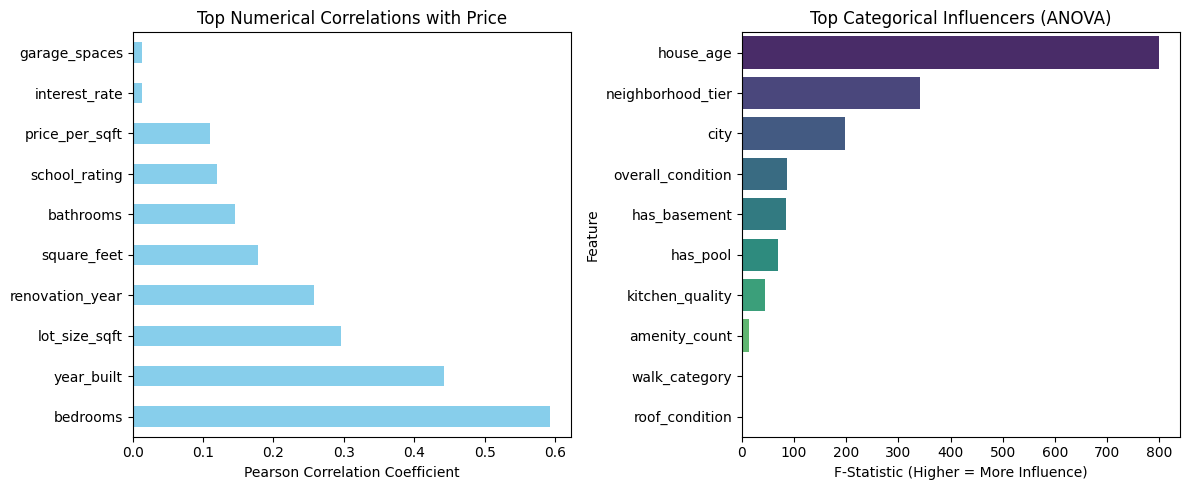

Top 5 Numerical Drivers:
 bedrooms           0.592293
year_built         0.442449
lot_size_sqft      0.296082
renovation_year    0.257473
square_feet        0.178596
Name: sale_price, dtype: float64

Top 5 Categorical Drivers:
              Feature  F-Statistic
3          house_age   799.452543
2  neighborhood_tier   340.492089
1               city   197.960931
6  overall_condition    87.383651
4       has_basement    84.620719


In [283]:

import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

def get_top_correlations(df, target='sale_price'):
    # 1. Numerical Correlation (Pearson)
    # Exclude the target itself and the leaky 'high_value_property' if it's numeric
    num_df = df.select_dtypes(include=[np.number])
    corrs = num_df.corr()[target].drop(target, errors='ignore')
    
    # Remove 'high_value_property' from analysis if it exists to avoid leakage
    if 'high_value_property' in corrs:
        corrs = corrs.drop('high_value_property')
        
    top_num = corrs.sort_values(ascending=False)

    # 2. Categorical Influence (ANOVA F-Statistic)
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    # Clean up categorical list
    ignore_cols = ['property_id', 'listing_date', 'high_value_property', target]
    cat_cols = [c for c in cat_cols if c not in ignore_cols]
    
    anova_results = []
    for col in cat_cols:
        # Group target by category levels
        groups = [group[target].values for name, group in df.groupby(col)]
        f_stat, p_val = stats.f_oneway(*groups)
        anova_results.append({'Feature': col, 'F-Statistic': f_stat})
    
    top_cat = pd.DataFrame(anova_results).sort_values(by='F-Statistic', ascending=False)

    return top_num, top_cat

# Execute the analysis
top_numerical, top_categorical = get_top_correlations(df_cleaned)

# --- VISUALIZATION ---

plt.figure(figsize=(12, 5))

# Plot 1: Top Numerical Correlations
plt.subplot(1, 2, 1)
top_numerical.head(10).plot(kind='barh', color='skyblue')
plt.title('Top Numerical Correlations with Price')
plt.xlabel('Pearson Correlation Coefficient')

# Plot 2: Top Categorical Influencers
plt.subplot(1, 2, 2)
sns.barplot(data=top_categorical.head(10), y='Feature', x='F-Statistic', palette='viridis')
plt.title('Top Categorical Influencers (ANOVA)')
plt.xlabel('F-Statistic (Higher = More Influence)')

plt.tight_layout()
plt.show()

# Print text summaries
print("Top 5 Numerical Drivers:\n", top_numerical.head(5))
print("\nTop 5 Categorical Drivers:\n", top_categorical.head(5))

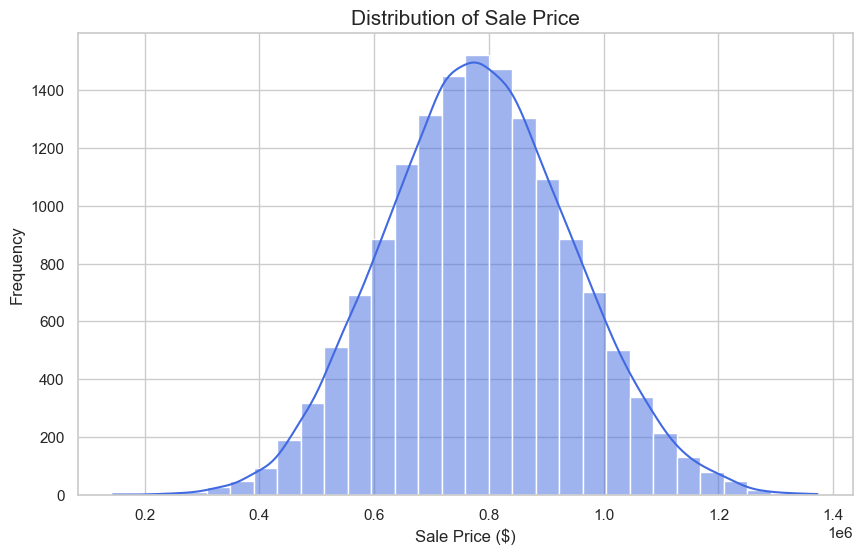

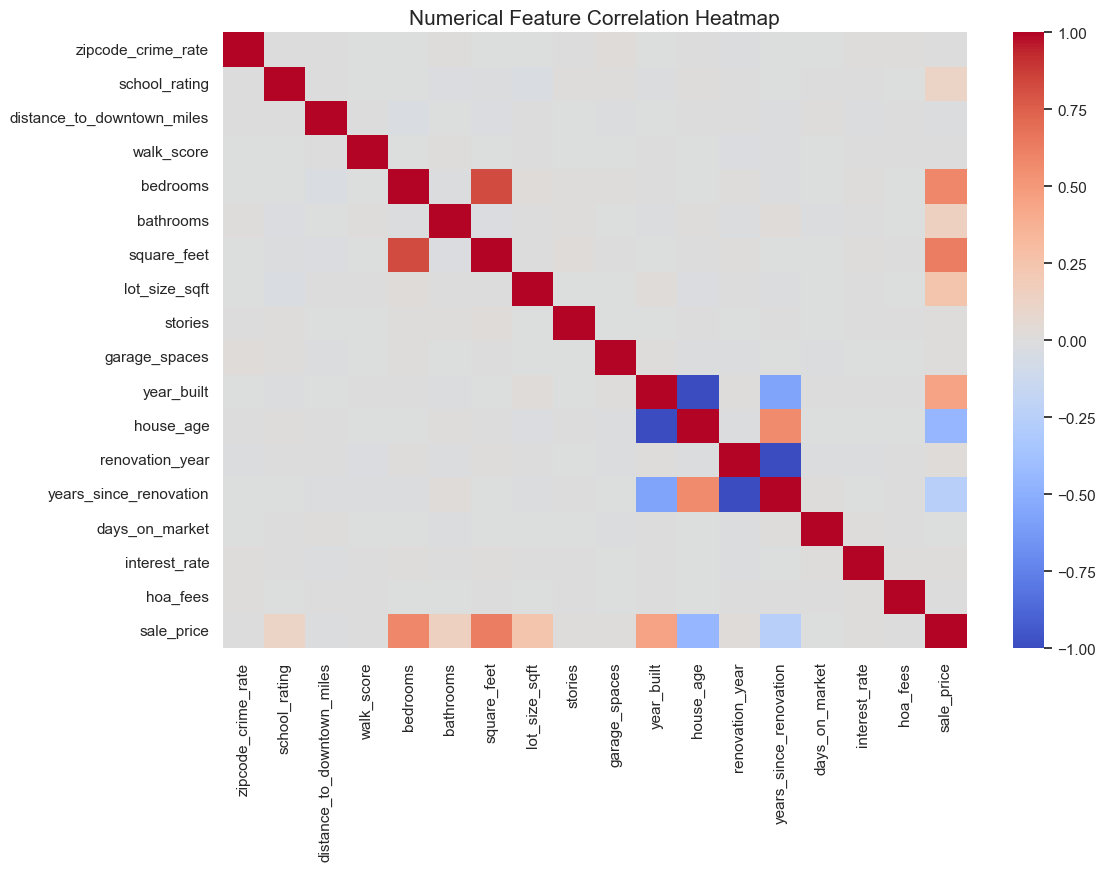

C:\Users\JaiGaneshK\AppData\Local\Temp\ipykernel_13160\1526057489.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='neighborhood_tier', y='sale_price', data=df, order=tier_order, palette='Set2')


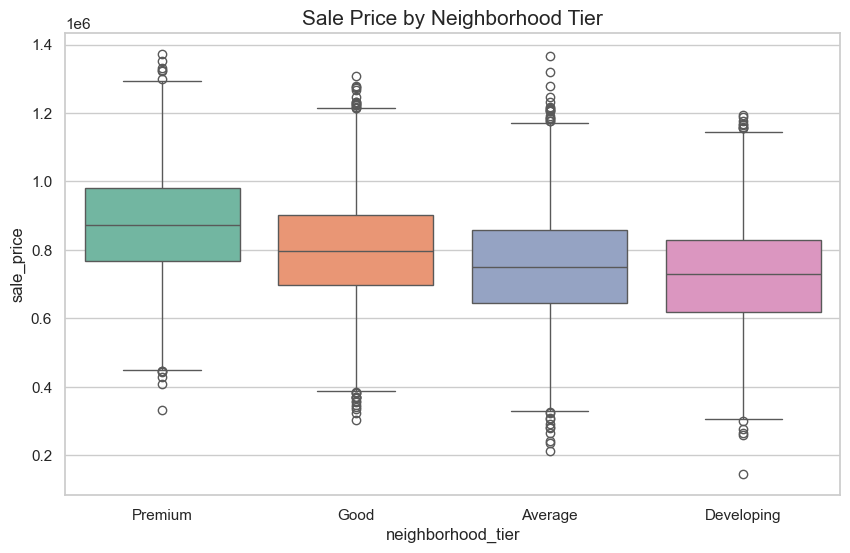

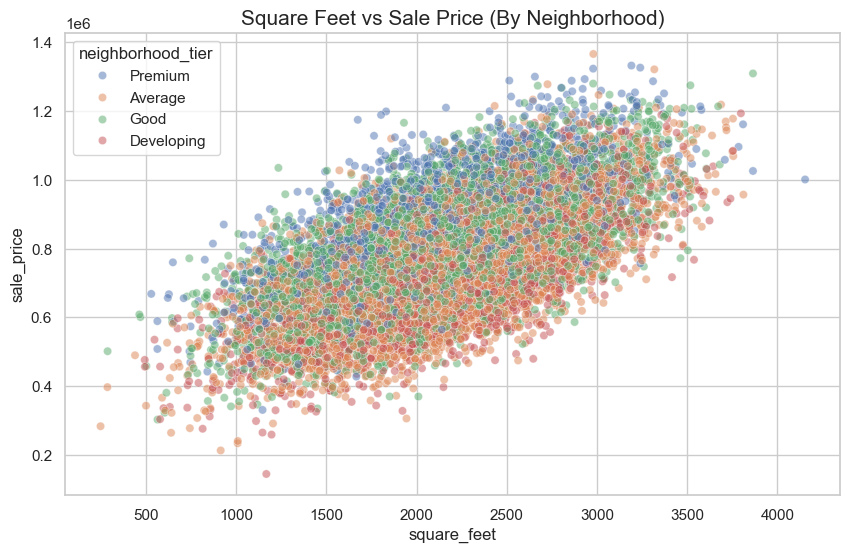

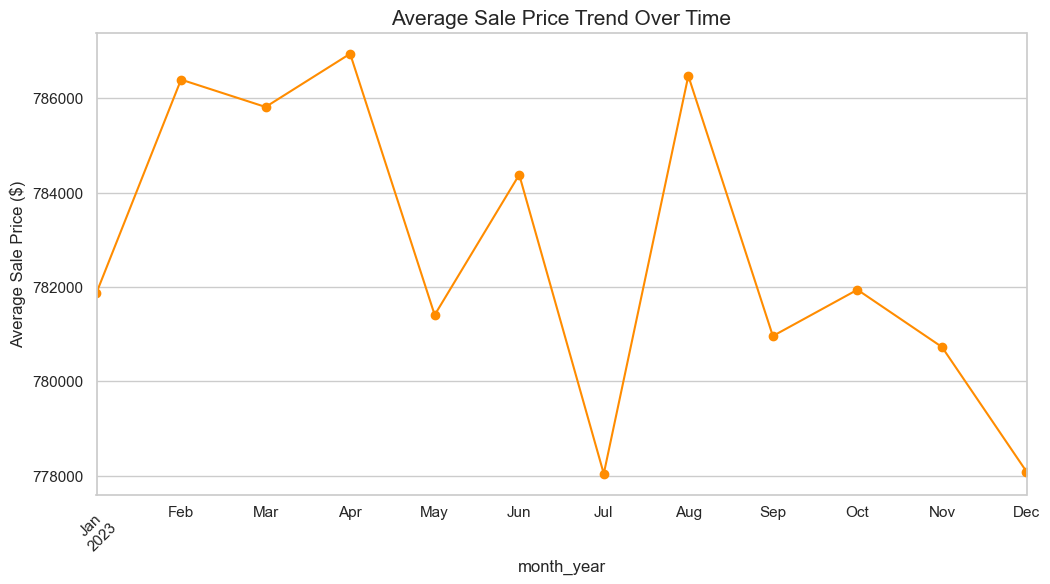

Missing Data Summary:
square_feet         750
renovation_year    8505
hoa_fees            750
dtype: int64


In [284]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('7_real_estate_prices.csv')

# --- 1. Data Cleaning & Preparation ---
# Convert listing_date to datetime format
df['listing_date'] = pd.to_datetime(df['listing_date'], dayfirst=True)

# Set the aesthetics for the plots
sns.set_theme(style="whitegrid")

# --- 2. Target Variable Analysis ---
plt.figure(figsize=(10, 6))
sns.histplot(df['sale_price'], kde=True, bins=30, color='royalblue')
plt.title('Distribution of Sale Price', fontsize=15)
plt.xlabel('Sale Price ($)')
plt.ylabel('Frequency')
plt.show()

# --- 3. Multi-variate Analysis: Heatmap ---
plt.figure(figsize=(12, 8))
# Calculating correlations for numerical columns only
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Numerical Feature Correlation Heatmap', fontsize=15)
plt.show()

# --- 4. Categorical Driver Analysis ---
# Looking at the most influential categorical feature: Neighborhood Tier
plt.figure(figsize=(10, 6))
tier_order = ['Premium', 'Good', 'Average', 'Developing']
sns.boxplot(x='neighborhood_tier', y='sale_price', data=df, order=tier_order, palette='Set2')
plt.title('Sale Price by Neighborhood Tier', fontsize=15)
plt.show()

# --- 5. Key Feature Relationship ---
# Square Feet vs Sale Price, segmented by Neighborhood Tier
plt.figure(figsize=(10, 6))
sns.scatterplot(x='square_feet', y='sale_price', hue='neighborhood_tier', data=df, alpha=0.5)
plt.title('Square Feet vs Sale Price (By Neighborhood)', fontsize=15)
plt.show()

# --- 6. Temporal Analysis (Seasonality) ---
df['month_year'] = df['listing_date'].dt.to_period('M')
monthly_avg = df.groupby('month_year')['sale_price'].mean()

plt.figure(figsize=(12, 6))
monthly_avg.plot(kind='line', marker='o', color='darkorange')
plt.title('Average Sale Price Trend Over Time', fontsize=15)
plt.ylabel('Average Sale Price ($)')
plt.xticks(rotation=45)
plt.show()

# --- 7. Missing Data Summary ---
print("Missing Data Summary:")
print(df.isnull().sum()[df.isnull().sum() > 0])